In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv(r"C:\Users\sakshi\Downloads\netflix.csv")

# Basic data exploration (run this first to understand the data)
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
print(df.describe(include='all'))

Dataset Shape: (8807, 12)

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2

Top 10 Genres:
 International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


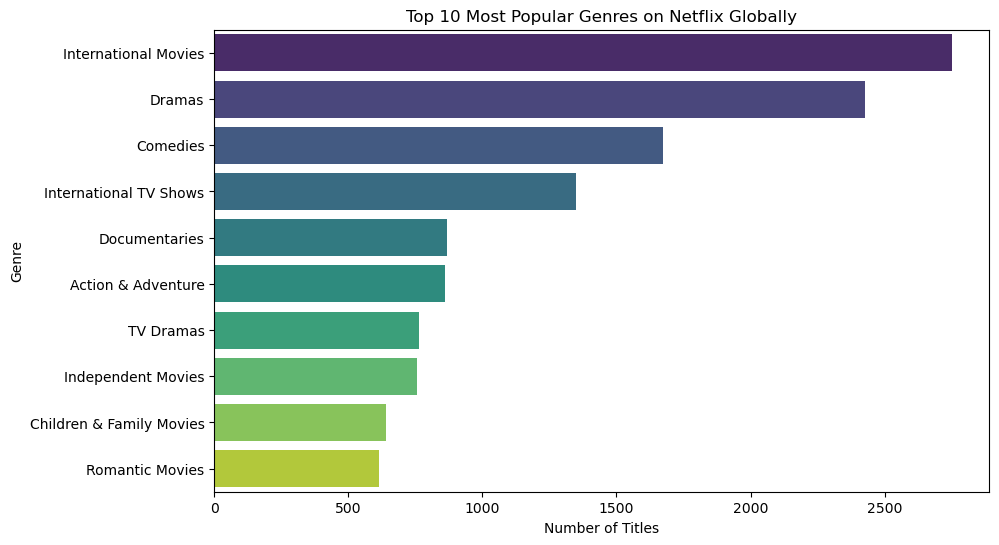

In [2]:
# Explode genres (split comma-separated)
genres = df['listed_in'].str.split(', ', expand=True).stack().reset_index(drop=True)
genre_counts = genres.value_counts().head(10)
print("Top 10 Genres:\n", genre_counts)

# Visualization: Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Popular Genres on Netflix Globally')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()  # Screenshot this bar chart

Top 5 Years with Highest Releases:
 release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


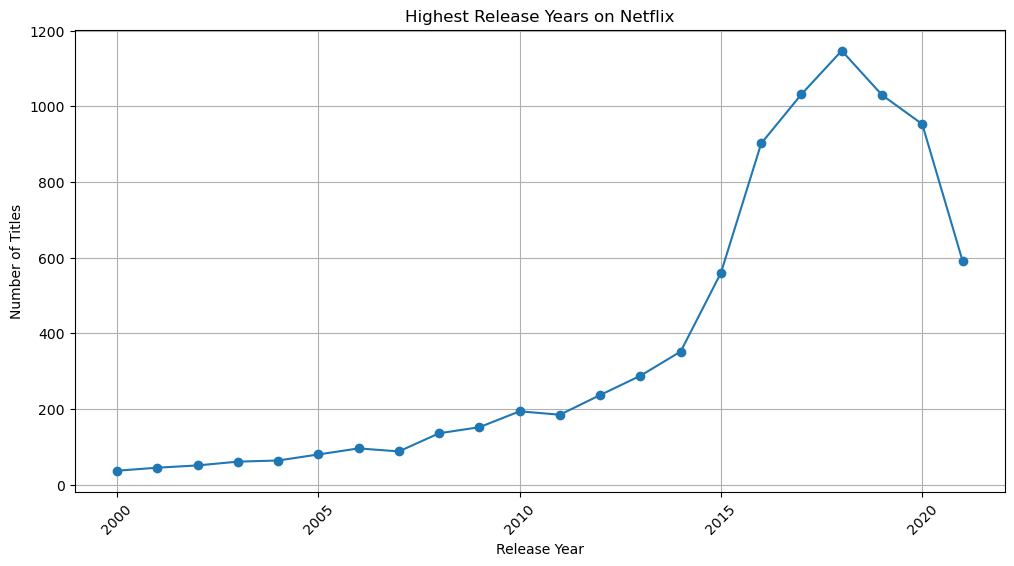

In [3]:
# Filter valid years (drop NaN)
df_year = df.dropna(subset=['release_year'])
year_counts = df_year['release_year'].value_counts().sort_index().tail(5)  # Top 5 recent
print("Top 5 Years with Highest Releases:\n", year_counts)

# Visualization: Line plot for all years (focus 2000+)
years_filtered = df_year[df_year['release_year'] >= 2000]['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(years_filtered.index, years_filtered.values, marker='o')
plt.title('Highest Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()  # Screenshot this line chart

Top 5 Countries:
 country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
Name: count, dtype: int64


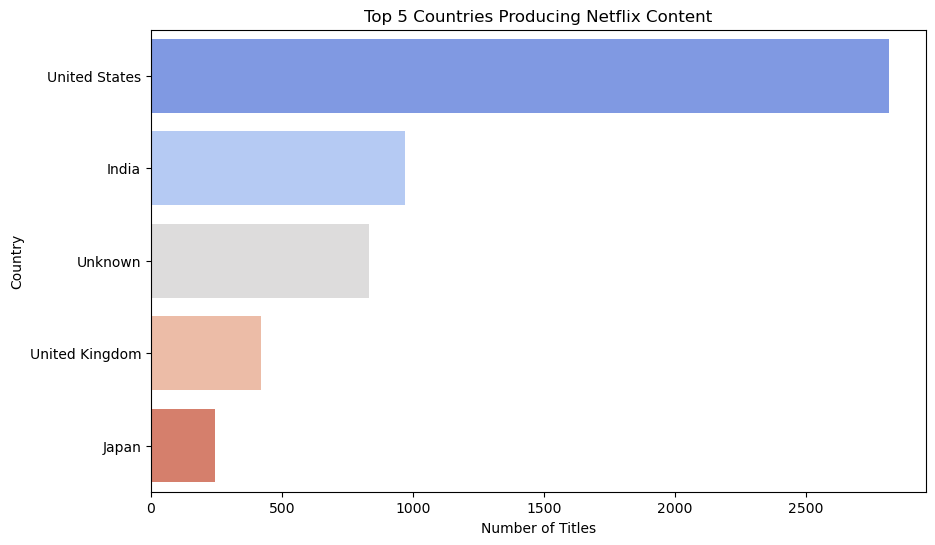

In [4]:
# Fill missing countries with 'Unknown'
df_country = df.copy()
df_country['country'] = df_country['country'].fillna('Unknown')

country_counts = df_country['country'].value_counts().head(5)
print("Top 5 Countries:\n", country_counts)

# Visualization: Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='coolwarm')
plt.title('Top 5 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()  # Screenshot this

Yearly Addition Trend (2010-2021):
 add_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


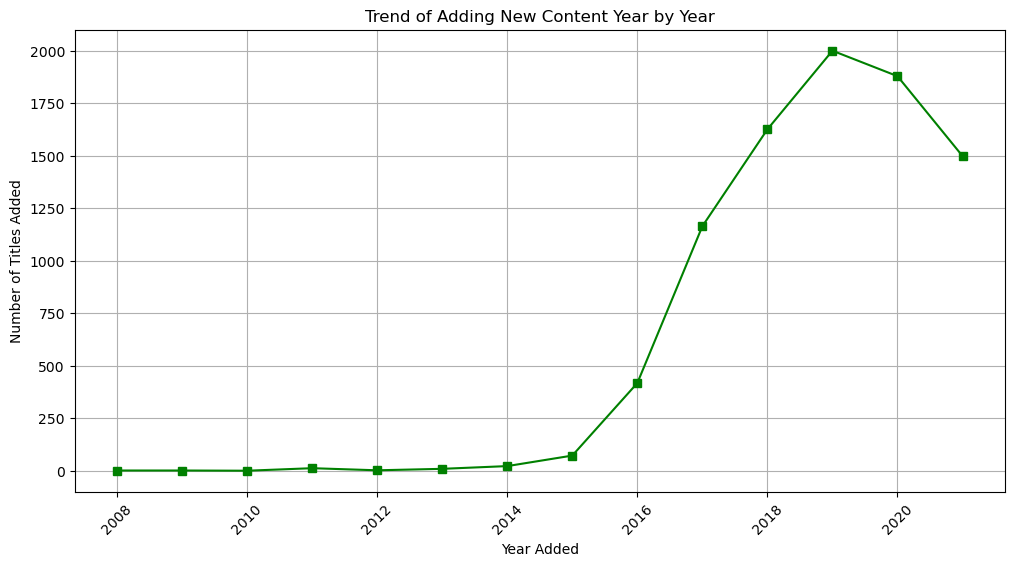

In [5]:
# Parse date_added to year (handle format issues)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['add_year'] = df['date_added'].dt.year

add_trend = df.dropna(subset=['add_year'])['add_year'].value_counts().sort_index()
print("Yearly Addition Trend (2010-2021):\n", add_trend)

# Visualization: Line plot
plt.figure(figsize=(12, 6))
plt.plot(add_trend.index, add_trend.values, marker='s', color='green')
plt.title('Trend of Adding New Content Year by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()  # Screenshot this

Top 5 Ratings:
 rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


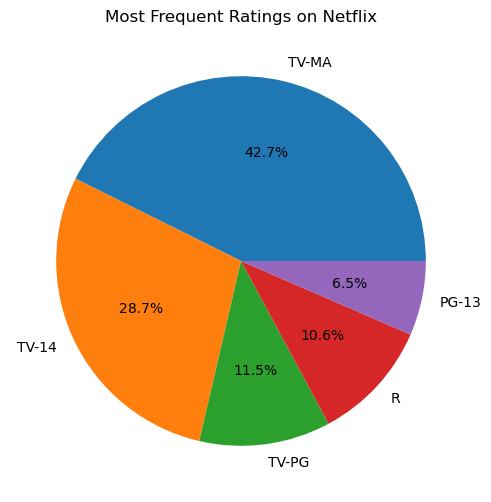

In [6]:
# Count ratings (fill NaN as 'Unknown')
df_rating = df.copy()
df_rating['rating'] = df_rating['rating'].fillna('Unknown')

rating_counts = df_rating['rating'].value_counts().head(5)
print("Top 5 Ratings:\n", rating_counts)

# Visualization: Pie chart
plt.figure(figsize=(8, 6))
plt.pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%')
plt.title('Most Frequent Ratings on Netflix')
plt.show()  # Screenshot this

Top 5 Countries % TV-MA:
 country
India             25.51
Japan             35.51
South Korea         NaN
Spain               NaN
United Kingdom    42.24
United States     32.93
Name: count, dtype: float64


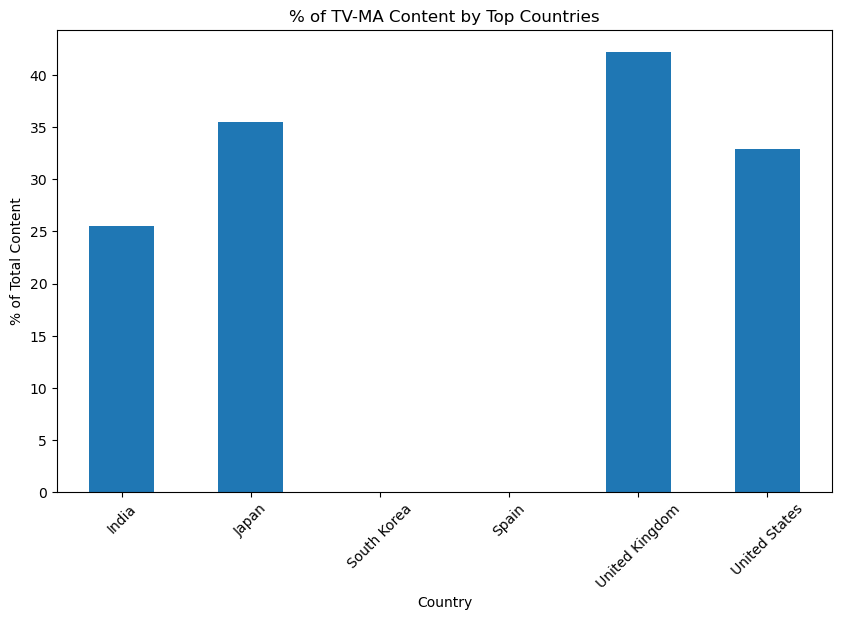

In [7]:
# Filter TV-MA
tv_ma = df[df['rating'] == 'TV-MA']

# Group by country, count
country_tvma = tv_ma['country'].value_counts().head(5)
total_country = df['country'].value_counts().head(5)
pct_tvma = (country_tvma / total_country * 100).round(2)
print("Top 5 Countries % TV-MA:\n", pct_tvma)

# Visualization: Bar chart
plt.figure(figsize=(10, 6))
pct_tvma.plot(kind='bar')
plt.title('% of TV-MA Content by Top Countries')
plt.xlabel('Country')
plt.ylabel('% of Total Content')
plt.xticks(rotation=45)
plt.show()  # Screenshot this

Top 5 Genres - Movies:
 International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

Top 5 Genres - TV Shows:
 International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Name: count, dtype: int64


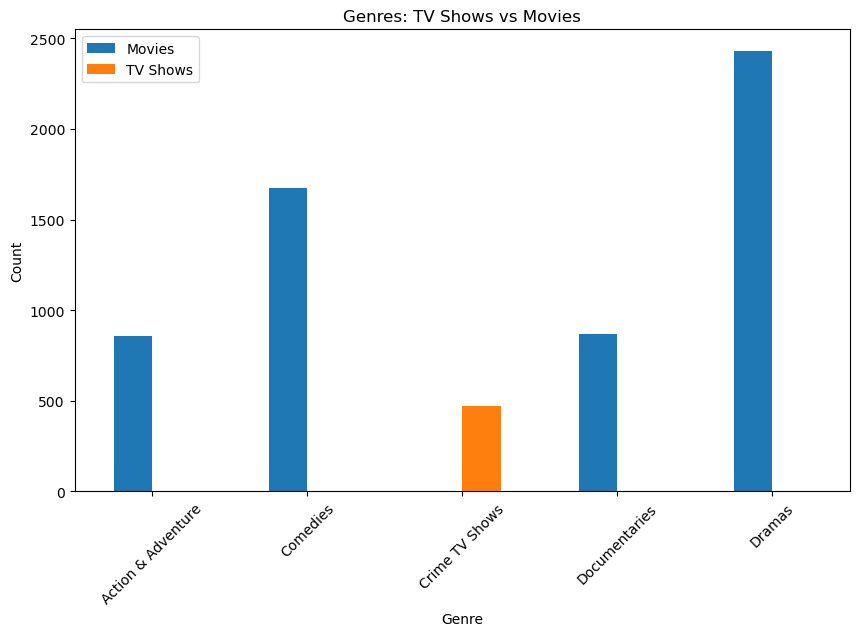

In [8]:
# Separate by type
movies = df[df['type'] == 'Movie']['listed_in'].str.split(', ', expand=True).stack().value_counts().head(5)
tvshows = df[df['type'] == 'TV Show']['listed_in'].str.split(', ', expand=True).stack().value_counts().head(5)

print("Top 5 Genres - Movies:\n", movies)
print("\nTop 5 Genres - TV Shows:\n", tvshows)

# Visualization: Grouped bar
genres_compare = pd.DataFrame({'Movies': movies, 'TV Shows': tvshows}).fillna(0).head(5)
genres_compare.plot(kind='bar', figsize=(10,6))
plt.title('Genres: TV Shows vs Movies')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()  # Screenshot this

Top US Genres:
 Dramas           591
Comedies         524
Documentaries    411
Name: count, dtype: int64

Top Non-US Genres:
 International Movies      2731
Dramas                    1836
International TV Shows    1324
Name: count, dtype: int64


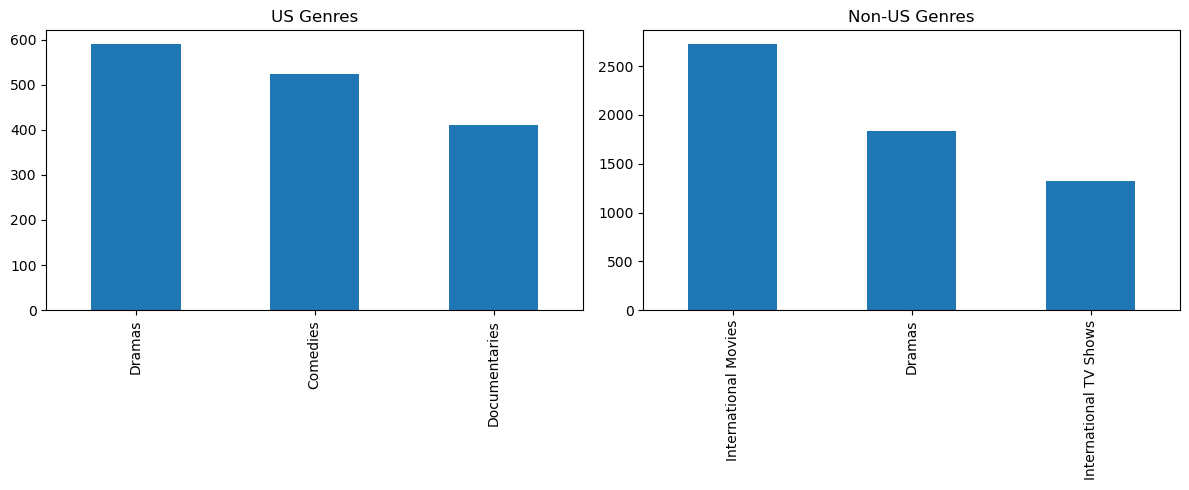

In [9]:
# US vs Others
us_df = df[df['country'] == 'United States']['listed_in'].str.split(', ', expand=True).stack().value_counts().head(3)
non_us = df[df['country'] != 'United States']['listed_in'].str.split(', ', expand=True).stack().value_counts().head(3)

print("Top US Genres:\n", us_df)
print("\nTop Non-US Genres:\n", non_us)

# Visualization: Side-by-side bar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
us_df.head(3).plot(kind='bar', ax=ax1)
ax1.set_title('US Genres')
non_us.head(3).plot(kind='bar', ax=ax2)
ax2.set_title('Non-US Genres')
plt.tight_layout()
plt.show()  # Screenshot this

Top Genres Last 3 Years:
 International Movies      662
International TV Shows    564
Dramas                    530
Comedies                  362
TV Dramas                 343
Name: count, dtype: int64


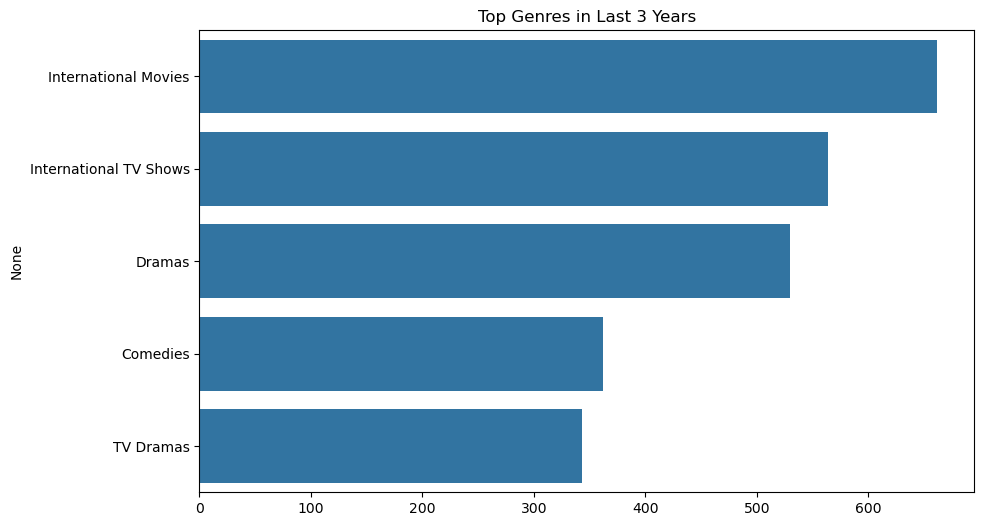

In [10]:
# Last 3 years (2019-2021)
recent = df[df['release_year'] >= 2019]['listed_in'].str.split(', ', expand=True).stack().value_counts().head(5)
print("Top Genres Last 3 Years:\n", recent)

# Visualization: Bar
plt.figure(figsize=(10,6))
sns.barplot(x=recent.values, y=recent.index)
plt.title('Top Genres in Last 3 Years')
plt.show()  # Screenshot this

Top 10 Directors:
 director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Youssef Chahine             12
Jay Chapman                 12
Name: count, dtype: int64


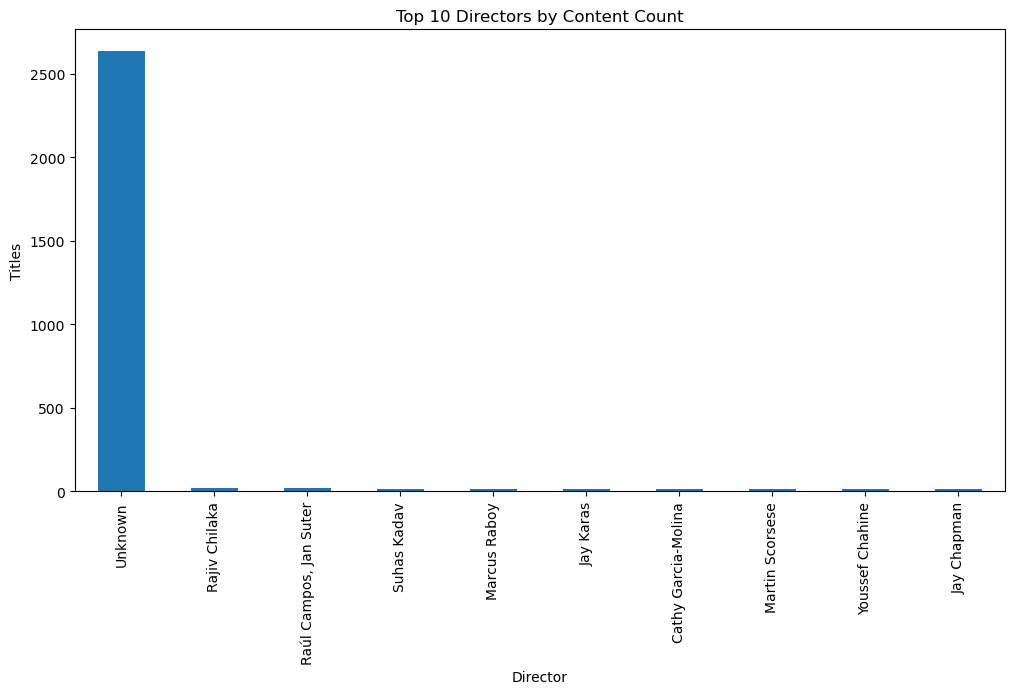

In [11]:
# Fill missing directors
df_dir = df.copy()
df_dir['director'] = df_dir['director'].fillna('Unknown')

top_directors = df_dir['director'].value_counts().head(10)
print("Top 10 Directors:\n", top_directors)

# Visualization: Bar
plt.figure(figsize=(12,6))
top_directors.plot(kind='bar')
plt.title('Top 10 Directors by Content Count')
plt.xlabel('Director')
plt.ylabel('Titles')
plt.xticks(rotation=90)
plt.show()  # Screenshot this

Top 10 Actors:
 Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


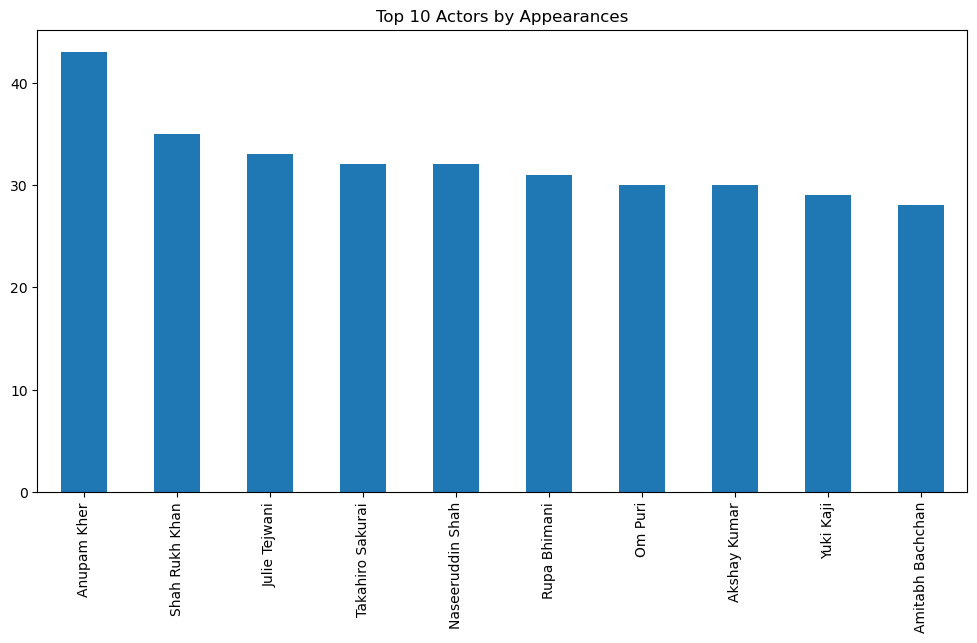

In [12]:
# Explode cast
cast_list = df['cast'].dropna().str.split(', ', expand=True).stack().reset_index(drop=True)
top_actors = cast_list.value_counts().head(10)
print("Top 10 Actors:\n", top_actors)

# Visualization: Bar
plt.figure(figsize=(12,6))
top_actors.plot(kind='bar')
plt.title('Top 10 Actors by Appearances')
plt.show()  # Screenshot this

In [13]:
# Create pairs (handle missing)
df_pairs = df.dropna(subset=['director', 'listed_in'])
pairs = []
for _, row in df_pairs.iterrows():
    for genre in row['listed_in'].split(', '):
        pairs.append((row['director'], genre))

pair_counts = Counter(pairs).most_common(10)
print("Top 10 Director-Genre Pairs:\n", pair_counts)

# Visualization: Table for simplicity (or bar if extended)
pair_df = pd.DataFrame(pair_counts, columns=['Pair', 'Count'])
print(pair_df)
# Bar plot example for top 5
top_pairs = pair_df.head(5)
top_pairs['Director'] = [p[0] for p in top_pairs['Pair']]
top_pairs['Genre'] = [p[1] for p in top_pairs['Pair']]
# (Extend with grouped bar if needed)

Top 10 Director-Genre Pairs:
 [(('Rajiv Chilaka', 'Children & Family Movies'), 19), (('Raúl Campos, Jan Suter', 'Stand-Up Comedy'), 18), (('Suhas Kadav', 'Children & Family Movies'), 16), (('Marcus Raboy', 'Stand-Up Comedy'), 15), (('Cathy Garcia-Molina', 'International Movies'), 13), (('Jay Karas', 'Stand-Up Comedy'), 13), (('Youssef Chahine', 'Dramas'), 12), (('Jay Chapman', 'Stand-Up Comedy'), 12), (('Youssef Chahine', 'International Movies'), 10), (('David Dhawan', 'Comedies'), 9)]
                                          Pair  Count
0    (Rajiv Chilaka, Children & Family Movies)     19
1    (Raúl Campos, Jan Suter, Stand-Up Comedy)     18
2      (Suhas Kadav, Children & Family Movies)     16
3              (Marcus Raboy, Stand-Up Comedy)     15
4  (Cathy Garcia-Molina, International Movies)     13
5                 (Jay Karas, Stand-Up Comedy)     13
6                    (Youssef Chahine, Dramas)     12
7               (Jay Chapman, Stand-Up Comedy)     12
8      (Youssef Chahine

In [14]:
unknown_dir = df['director'].isnull().sum()
unknown_cast = df['cast'].isnull().sum()
total_unknown = unknown_dir + unknown_cast
print(f"Unknown Directors: {unknown_dir}")
print(f"Unknown Cast: {unknown_cast}")
print(f"Total Titles with Unknowns: {total_unknown}")

Unknown Directors: 2634
Unknown Cast: 825
Total Titles with Unknowns: 3459


Number of bad duration extractions: 3
Average Movie Duration: 99.58 minutes


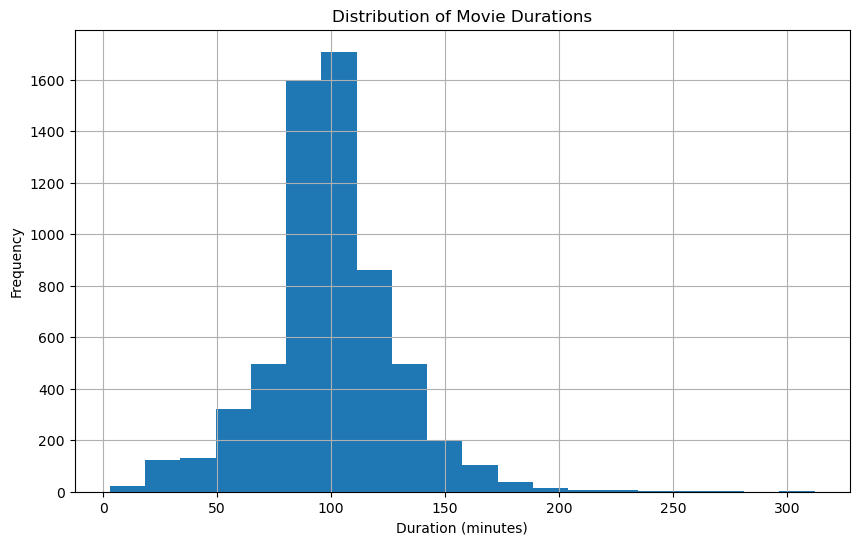

In [15]:
# Filter movies, convert duration (handles NaNs/edges)
movies_df = df[df['type'] == 'Movie'].copy()

# Extract digits as series, convert safely to numeric (NaN for failures)
extracted = movies_df['duration'].str.extract('(\d+)')[0]  # Get the single column as series
movies_df['duration_min'] = pd.to_numeric(extracted, errors='coerce')

# Check for issues (should be 0)
bad_extractions = movies_df['duration_min'].isna().sum()
print(f"Number of bad duration extractions: {bad_extractions}")

avg_duration = movies_df['duration_min'].mean()
print(f"Average Movie Duration: {avg_duration:.2f} minutes")

# Visualization: Histogram (drop NaNs if any)
movies_df['duration_min'].dropna().hist(bins=20, figsize=(10,6))
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()  # Screenshot this histogram

Most Common Seasons: 1


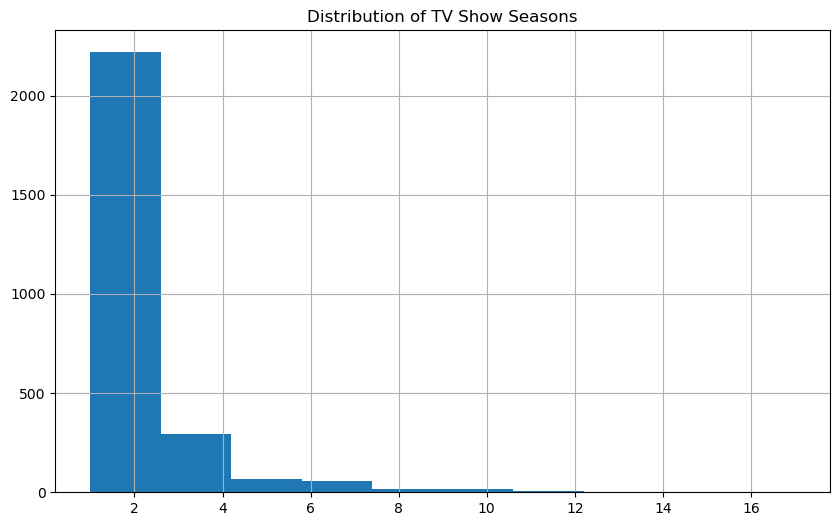

In [16]:
# Filter TV shows, extract seasons (e.g., '2 Seasons' -> 2)
tv_df = df[df['type'] == 'TV Show'].copy()
tv_df['seasons'] = tv_df['duration'].str.extract('(\d+)').astype(int)
most_common = tv_df['seasons'].mode()[0]
print(f"Most Common Seasons: {most_common}")

# Visualization: Histogram
plt.figure(figsize=(10,6))
tv_df['seasons'].hist(bins=10)
plt.title('Distribution of TV Show Seasons')
plt.show()  # Screenshot this

Trend (Last 20 Years):
 release_year
2002    119.55
2003    116.27
2004    114.33
2005    113.93
2006    113.01
2007    113.23
2008    106.24
2009    108.95
2010    104.46
2011    102.87
2012    100.76
2013     98.05
2014    100.26
2015     99.51
2016     95.36
2017     95.54
2018     96.19
2019     93.47
2020     92.14
2021     96.44
Name: duration_min, dtype: float64


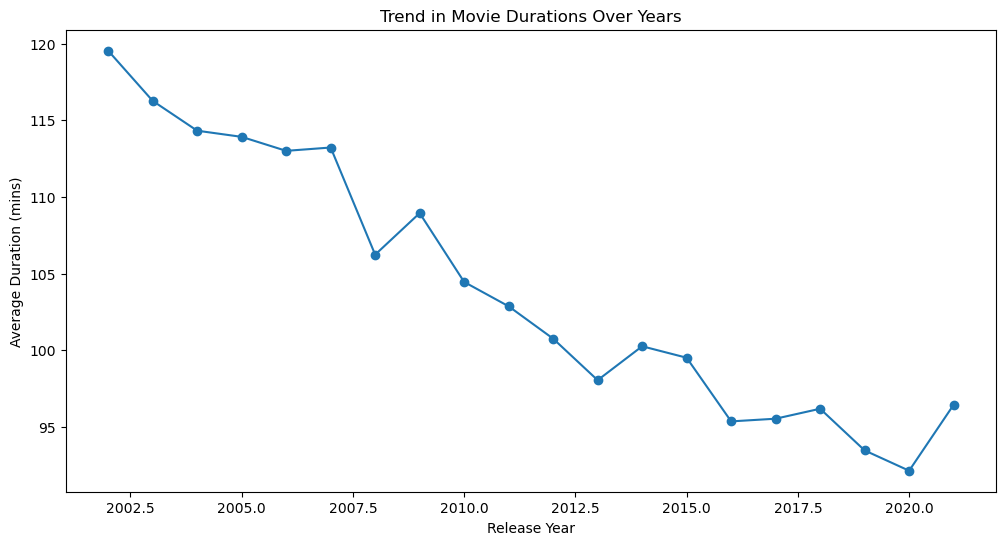

In [17]:
# Add duration_min to movies_df from Q15
movies_trend = movies_df.groupby('release_year')['duration_min'].mean().tail(20)  # Last 20 years
print("Trend (Last 20 Years):\n", movies_trend.round(2))

# Visualization: Line
plt.figure(figsize=(12,6))
movies_trend.plot(marker='o')
plt.title('Trend in Movie Durations Over Years')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (mins)')
plt.show()  # Screenshot this

Top 3 Months for Additions:
 add_month
July         819
December     797
September    765
Name: count, dtype: int64


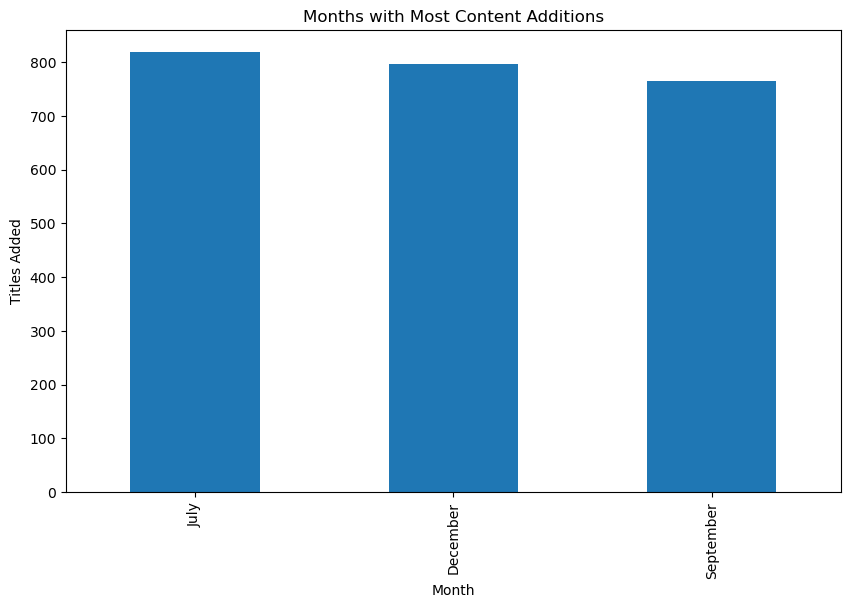

In [18]:
# Extract month
df['add_month'] = df['date_added'].dt.month_name()
month_counts = df.dropna(subset=['add_month'])['add_month'].value_counts().head(3)
print("Top 3 Months for Additions:\n", month_counts)

# Visualization: Bar
plt.figure(figsize=(10,6))
month_counts.plot(kind='bar')
plt.title('Months with Most Content Additions')
plt.xlabel('Month')
plt.ylabel('Titles Added')
plt.show()  # Screenshot this

Top Genre per Year (2018-2021):
    release_year               listed_in
0          2018    International Movies
1          2019    International Movies
2          2020    International Movies
3          2021  International TV Shows


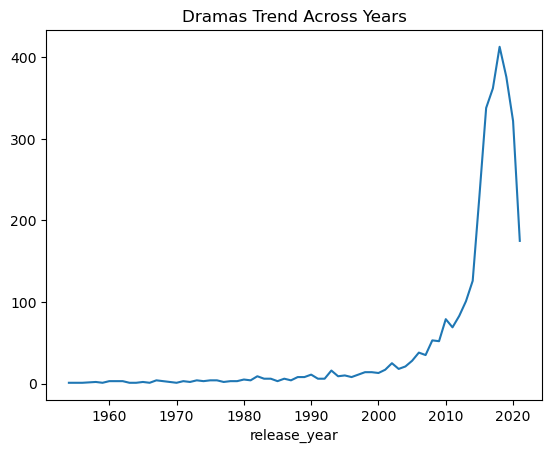

In [19]:
# For recent years
recent_df = df[df['release_year'] >= 2018]
year_genre = recent_df.groupby('release_year')['listed_in'].apply(lambda x: x.str.split(', ').explode().value_counts().index[0]).reset_index()
print("Top Genre per Year (2018-2021):\n", year_genre)

# Visualization: (Use stacked bar for full, but simple line for top genre count)
# Example: Count Dramas per year
drama_per_year = df[df['listed_in'].str.contains('Dramas')].groupby('release_year').size()
drama_per_year.plot()
plt.title('Dramas Trend Across Years')
plt.show()  # Screenshot this

Top 10 Genre-Country Pairs:
 [(('International Movies', 'India'), 817), (('Dramas', 'India'), 620), (('Dramas', 'United States'), 591), (('Comedies', 'United States'), 524), (('Documentaries', 'United States'), 411), (('Comedies', 'India'), 308), (('Independent Movies', 'United States'), 302), (('Children & Family Movies', 'United States'), 272), (('Action & Adventure', 'United States'), 249), (('TV Comedies', 'United States'), 234)]

Sample pair_df:
                              pair  count                 genre        country
0   (International Movies, India)    817  International Movies          India
1                 (Dramas, India)    620                Dramas          India
2         (Dramas, United States)    591                Dramas  United States
3       (Comedies, United States)    524              Comedies  United States
4  (Documentaries, United States)    411         Documentaries  United States

Top 5 Genres: ['International Movies', 'Dramas', 'Comedies', 'Independent M

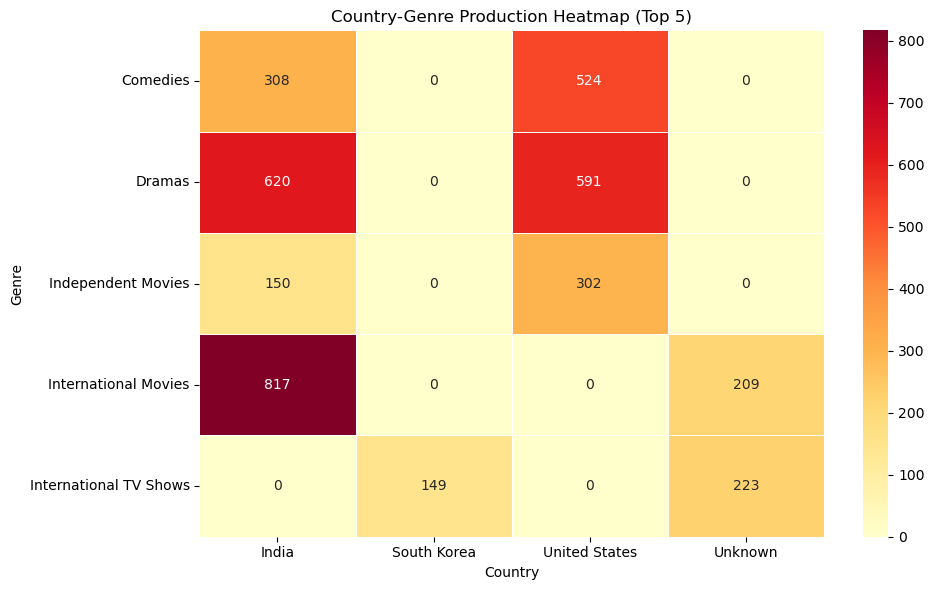

In [20]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Build list of (genre, country) pairs (handle NaNs)
genres_country = []
for _, row in df.iterrows():
    if pd.isna(row['listed_in']) or row['listed_in'] == '':
        continue  # Skip empty genres
    genres = [g.strip() for g in row['listed_in'].split(', ')]
    country = row['country'] if pd.notna(row['country']) else 'Unknown'
    for g in genres:
        genres_country.append((g, country))

# Step 2: Count top pairs
all_pairs_counter = Counter(genres_country)
top_per_genre = all_pairs_counter.most_common(20)  # Top 20 for buffer
print("Top 10 Genre-Country Pairs:\n", top_per_genre[:10])  # Sample output

# Step 3: Create DataFrame and split pairs
pair_df = pd.DataFrame(top_per_genre, columns=['pair', 'count'])
pair_df['genre'] = [p[0] for p in pair_df['pair']]
pair_df['country'] = [p[1] for p in pair_df['pair']]
print("\nSample pair_df:\n", pair_df.head())

# Step 4: Get top 5 genres and countries for heatmap
top_genres = pair_df['genre'].value_counts().head(5).index.tolist()
top_countries = pair_df['country'].value_counts().head(5).index.tolist()
print(f"\nTop 5 Genres: {top_genres}")
print(f"Top 5 Countries: {top_countries}")

# Step 5: Filter and pivot
filtered_df = pair_df[pair_df['genre'].isin(top_genres) & pair_df['country'].isin(top_countries)]
pivot = filtered_df.pivot_table(values='count', index='genre', columns='country', aggfunc='sum', fill_value=0)

print("\nPivot Table (Top 5 Genres x Top 5 Countries):\n", pivot)
print("Pivot Shape:", pivot.shape)

# Step 6: Visualization - Heatmap (only if non-empty)
if pivot.size > 0 and pivot.shape[0] > 0 and pivot.shape[1] > 0:
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='d', linewidths=0.5)
    plt.title('Country-Genre Production Heatmap (Top 5)')
    plt.xlabel('Country')
    plt.ylabel('Genre')
    plt.tight_layout()
    plt.show()  # Screenshot this heatmap
else:
    print("Pivot is empty - check data filtering")